In [10]:
import sys
import numpy as np
import anndata as ad
from markdown_it.common.html_re import cdata

sys.path.insert(0, '..')

import src as scit
import anndata as ad

In [11]:
adata = ad.read_h5ad('private/data/clean_method/combined_wt.h5ad')

In [12]:
scit.ld.gtf('private/data/dmel-all-r6.56.gtf').df

chr,strand,start,end,id
str,str,i64,i64,str
"""chrX""","""+""",19961297,19969323,"""Nep3"""
"""chrX""","""+""",20025099,20025170,"""tRNA:Pro-CGG-1-1"""
"""chrX""","""+""",20051294,20052519,"""CG9570"""
"""chrX""","""+""",20094398,20095767,"""Or19b"""
"""chrX""","""+""",20133579,20138878,"""CG15322"""
…,…,…,…,…
"""chr2L""","""-""",813314,815950,"""Saf6"""
"""chr2L""","""-""",786153,790798,"""Pkg21D"""
"""chr2L""","""-""",737212,744395,"""Eaat2"""


In [20]:
import pickle

rna = ad.read_h5ad('../data/scglue/user/emb-rna.h5ad')
#reg = scit.ld.regulatory_links('../data/scglue/user/bin.links', rna)
import pandas as pd
class Reg:
    def __init__(self):
        pass
reg = Reg()
reg.df = pd.DataFrame(columns=["chr", "start", "end", "chr2", "start2", "end2", "score", "pval", "qval", "name", "binname"])
scit.tl.regulatory_ensure_promoter_included(reg, adata, rna)

# Get sparse adjacency matrix of regulation (n gene features x n bin features)

R = scit.tl.get_regulatory_matrix(reg, rna.var_names, adata.var_names)

In [21]:
#import polars as pl
#names = pl.read_csv('private/rna_features.csv')['column_0'].to_numpy()
names = np.array(rna.var_names.to_list())

In [22]:
# Alternatively, create a regulatory matrix by linking gene to bins
# in a sparse binary csr matrix.

# import scipy.sparse as sps
# R = sps.csr_matrix( ..., dtype=np.bool_)

In [24]:
lc_meth = scit.tl.make_layer_config('meth')
lc_acet = scit.tl.make_layer_config('acet')

# Infer gene acetylation/methylation layers
scit.tl.infer_layer(adata, R, lc_acet, names, 'acet')
scit.tl.infer_layer(adata, R, lc_meth, names, 'meth')

In [25]:
adata.obsm['X_umap'][:,1] = -adata.obsm['X_umap'][:,1]

In [26]:
adata.write_h5ad('private/data/clean_method/cttag_wt_inferred_promoters.h5ad')

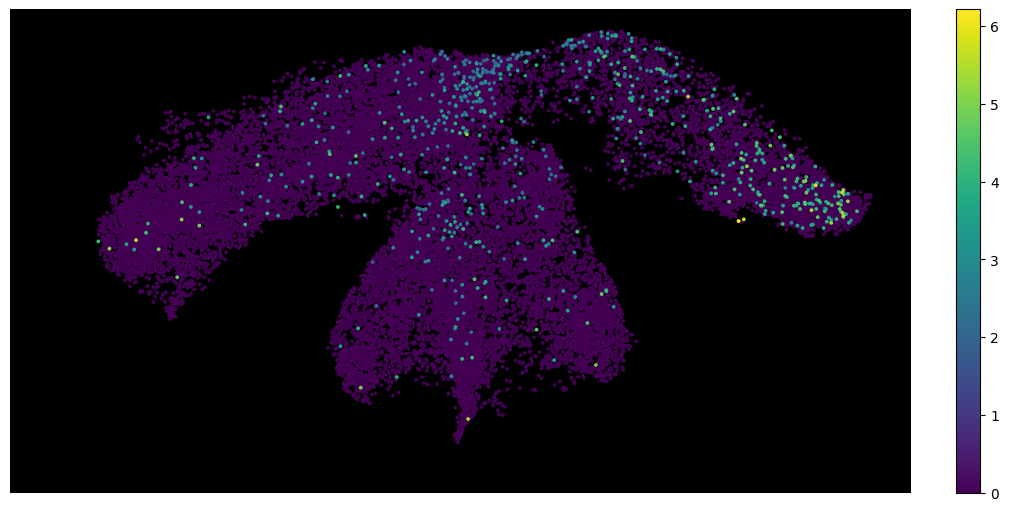

In [27]:
# The inferred data is in .obsm (since feature number is different)
acet = scit.tl.make_layer_config('acet', in_obsm=True, normalize_with_obs_counts=True, log_transform=True, feature_names=names)

# Visualize Oli gene acetylation
# The layer to infer Oli regulation is binary,
# however, the inferred layer divides signal by total number of
# involved bins (Oli regulation is spread over 9 bins)
scit.tl.layer_pick_features(adata, acet, 'Oli')
scit.tl.copy_to_obs(adata, acet)
scit.pl.embedding2d(adata, 'X_umap', 'copied_data', black_background=True)

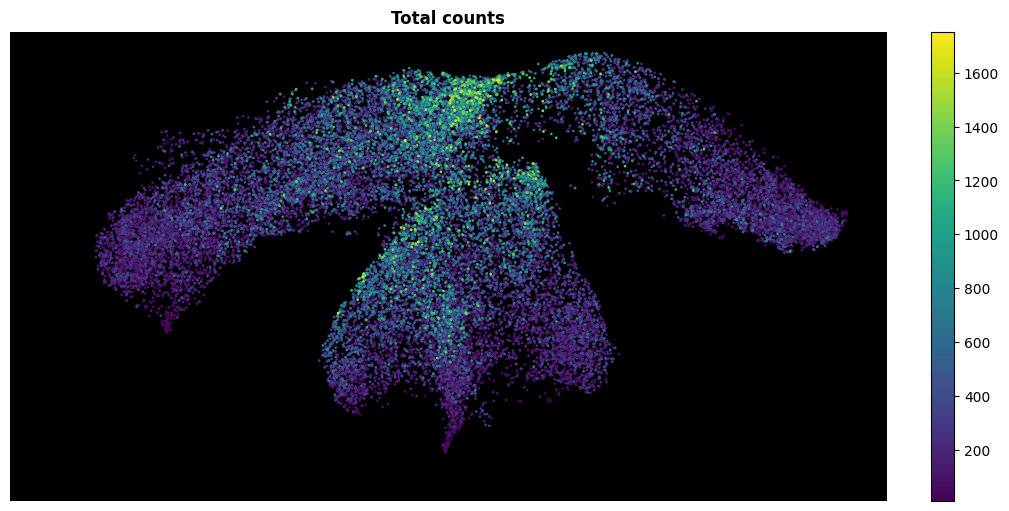

In [28]:
lc_acet_full = scit.tl.make_layer_config(
    'acet', in_obsm=True, feature_active_threshold=0
)
X = lc_acet_full.transform(adata, binarize=True)
adata.obs['copied_data'] = X.sum(axis=1).A1
scit.pl.embedding2d(adata, 'X_umap', 'copied_data', size=1, black_background=True, title='Total counts')